# Superzone Conservation Test of the TAZ Hybrid — and a Jointly-Constrained Fix

**Question (methodology review, 21 Sep 2026, §5).** The TAZ hybrid is built as
$\tilde C_{ij} = C_{ij}\,R_{AB}$ followed by row normalization and origin volumes
split within each superzone by cellular outflow shares. The notebooks assert that
**origin totals** reaggregate to the superzone survey departures. They do not assert —
and this construction does not guarantee — that the **superzone OD blocks**
$\sum_{i\in A,\,j\in B} T_{ij}$ reproduce the superzone hybrid $T^*_{AB}$, because the
row normalization of each fine row happens *after* the block-wise correction and the
fine rows inside a superzone carry different cellular destination mixes.

This notebook (1) measures the deviation for the primary (trips-file) hybrid and the
historical (activities-file) hybrid, and (2) rebalances the primary hybrid so that both
constraints hold at once — superzone OD blocks *and* TAZ origin totals — by iterative
proportional fitting with the current hybrid as the seed. The balanced matrix is saved
as a separate product (`hybrid_taz_trips_balanced.csv`); the pass/fail assertion at the
end is the regression check the review asked for.

Inputs are committed outputs only (`Output/ths2017/study_taz/hybrid_taz_trips.csv`,
`hybrid_sz_trips.csv`, the historical `Output/hybrid_*`), plus the TAZ → superzone map
recorded in `Output/ths2017/three_mode_2022/growth_factors_taz_2018_2022.csv` (identical
to `SZ_NEW` of the keys table for all 778 TAZs).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, INK, INK2, MUTED, GRID, AXIS = '#2a78d6', '#eb6834', '#1baf7a', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
OUT = 'Output/ths2017/tests'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)

def load_sq(path):
    m = pd.read_csv(path, index_col=0); m.index = m.index.astype(int); m.columns = m.columns.astype(int); return m
sz_map = pd.read_csv('Output/ths2017/three_mode_2022/growth_factors_taz_2018_2022.csv').set_index('TAZ')['SZ']

def reaggregate(taz, sz):
    taz = taz.loc[[t for t in taz.index if t in sz_map.index], [t for t in taz.columns if t in sz_map.index]]
    o, d = taz.index.map(sz_map), taz.columns.map(sz_map)
    agg = taz.groupby(o).sum().T.groupby(d).sum().T
    return agg.reindex(index=sz.index, columns=sz.columns).fillna(0), taz

def block_report(agg, sz, label, min_trips=100):
    diff, rel = agg - sz, (agg - sz) / sz.replace(0, np.nan)
    big = sz > min_trips; off = ~np.eye(len(sz), dtype=bool)
    rt, ct = agg.sum(axis=1) - sz.sum(axis=1), agg.sum(axis=0) - sz.sum(axis=0)
    r = {'matrix': label, 'total TAZ': agg.values.sum(), 'total SZ': sz.values.sum(),
         'origin totals max |rel|': (rt / sz.sum(axis=1)).abs().max(), 'dest totals max |rel|': (ct / sz.sum(axis=0)).abs().max(),
         f'blocks > {min_trips}': int(big.sum().sum()), '|rel| > 10 %': int(((rel.abs() > 0.10) & big).sum().sum()), '|rel| > 25 %': int(((rel.abs() > 0.25) & big).sum().sum()),
         'flow-weighted mean |rel| (blocks)': diff.abs()[big].sum().sum() / sz[big].sum().sum(),
         'max |rel| (blocks)': rel[big].abs().max().max(),
         'diagonal ratio min': np.nanmin(np.diag(agg.values) / np.diag(sz.values)), 'diagonal ratio median': np.nanmedian(np.diag(agg.values) / np.diag(sz.values)),
         'off-diagonal ratio': agg.values[off].sum() / sz.values[off].sum()}
    return r, diff, rel

## 1. Does the TAZ hybrid reproduce its superzone targets?

In [2]:
SETS = {'primary (trips file, Output/ths2017/study_taz)': ('Output/ths2017/study_taz/hybrid_taz_trips.csv', 'Output/ths2017/study_taz/hybrid_sz_trips.csv'),
        'historical (activities file, Output/)': ('Output/hybrid_taz_trips.csv', 'Output/hybrid_sz_trips.csv')}
rows, REL = [], {}
for label, (taz_p, sz_p) in SETS.items():
    taz, sz = load_sq(taz_p), load_sq(sz_p)
    agg, _ = reaggregate(taz, sz)
    r, diff, rel = block_report(agg, sz, label); rows.append(r); REL[label] = (agg, sz, diff, rel)
rep = pd.DataFrame(rows).set_index('matrix').T
rep.to_csv(f'{OUT}/hybrid_sz_conservation_summary.csv', float_format='%.4f')
print("reaggregated TAZ hybrid vs superzone hybrid:"); rep.round(4)

reaggregated TAZ hybrid vs superzone hybrid:


matrix,"primary (trips file, Output/ths2017/study_taz)","historical (activities file, Output/)"
total TAZ,2.068158e+06,2.152928e+06
total SZ,2.068158e+06,2.152928e+06
origin totals max |rel|,0.000000e+00,6.720000e-02
dest totals max |rel|,2.560000e-02,1.201000e-01
blocks > 100,6.270000e+02,5.800000e+02
|rel| > 10 %,5.500000e+01,8.000000e+01
|rel| > 25 %,1.200000e+01,2.000000e+01
flow-weighted mean |rel| (blocks),2.020000e-02,2.540000e-02
max |rel| (blocks),4.898000e-01,5.457000e-01
diagonal ratio min,9.414000e-01,9.057000e-01


In [3]:
agg, sz, diff, rel = REL['primary (trips file, Output/ths2017/study_taz)']
s = sz.stack(); s = s[s > 500]; r = rel.stack()[s.index]
worst = pd.DataFrame({'superzone target': s, 'TAZ hybrid reaggregated': agg.stack()[s.index], 'rel diff': r}).reindex(r.abs().sort_values(ascending=False).index[:12])
worst.index.names = ['origin SZ', 'dest SZ']; worst.round(3).to_csv(f'{OUT}/hybrid_sz_conservation_worst_blocks.csv')
print("largest block deviations (targets > 500 trips), primary hybrid:"); worst.round(2)

largest block deviations (targets > 500 trips), primary hybrid:


superzone target  TAZ hybrid reaggregated  rel diff
origin SZ dest SZ                                                     
35        3                 1495.06                  2227.38      0.49
          2                  590.25                   823.45      0.40
21        19                1299.39                  1739.82      0.34
35        33                 521.77                   674.90      0.29
11        7                  692.59                   895.01      0.29
21        35                 811.31                  1016.26      0.25
          9                  540.78                   651.43      0.20
32        35                 637.52                   759.75      0.19
11        15                 528.24                   628.80      0.19
21        20                1410.66                  1666.62      0.18
11        3                  558.25                   655.48      0.17
19        35                3521.25                  4090.92      0.16

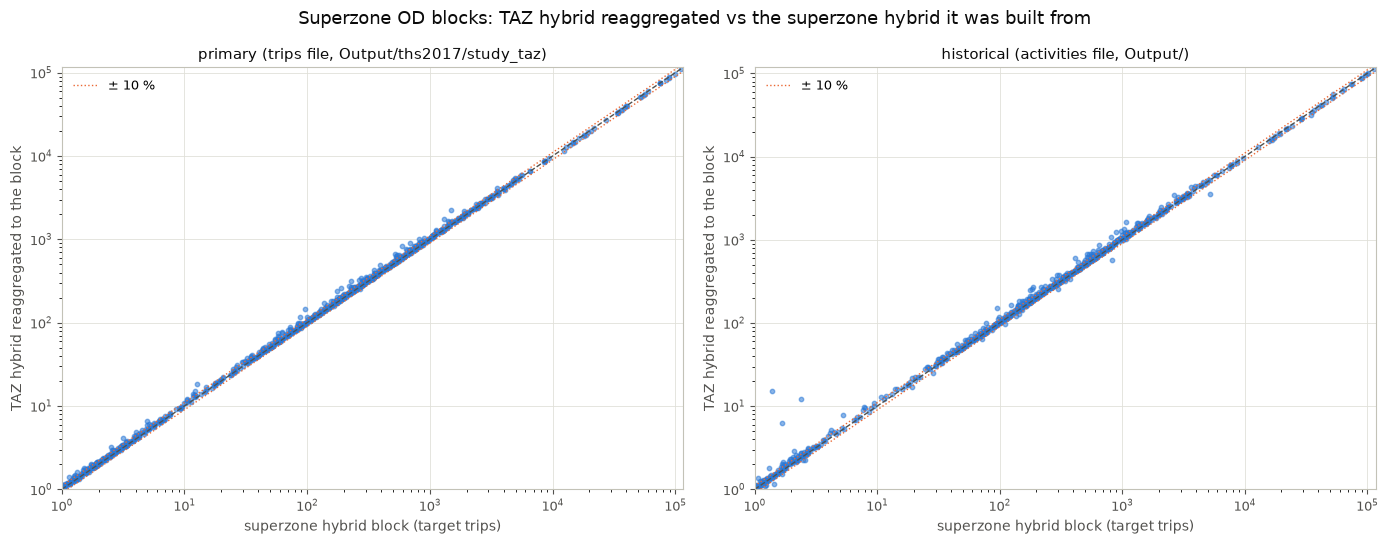

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')
for ax, label in zip(axes, SETS):
    agg, sz, diff, rel = REL[label]
    x, y = sz.values.ravel(), agg.values.ravel(); m = x > 0
    ax.scatter(x[m], y[m], s=10, alpha=0.55, color=BLUE)
    lim = max(x.max(), y.max()) * 1.05; ax.plot([1, lim], [1, lim], color=INK2, linestyle='--', linewidth=1)
    ax.plot([1, lim], [1.1, lim * 1.1], color=ORANGE, linestyle=':', linewidth=1); ax.plot([1, lim], [0.9, lim * 0.9], color=ORANGE, linestyle=':', linewidth=1, label='± 10 %')
    ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(1, lim); ax.set_ylim(1, lim)
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for sp in ax.spines.values(): sp.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9); ax.set_title(label, color=INK, fontsize=11)
    ax.set_xlabel('superzone hybrid block (target trips)', color=INK2); ax.set_ylabel('TAZ hybrid reaggregated to the block', color=INK2); ax.legend(frameon=False, fontsize=9)
fig.suptitle('Superzone OD blocks: TAZ hybrid reaggregated vs the superzone hybrid it was built from', color=INK, fontsize=13)
plt.tight_layout(); fig.savefig('Output/figures/hybrid_sz_conservation.png', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 2. Jointly-constrained rebalancing of the primary TAZ hybrid

Seed: the current `hybrid_taz_trips.csv`. Constraints, imposed alternately until both
hold (three-dimensional IPF): every superzone OD block equals the superzone hybrid
$T^*_{AB}$, and every TAZ origin total equals the current within-superzone split
(survey superzone departures × cellular outflow share — unchanged, so the origin
volumes the earlier notebooks published are kept). Column totals are free. Cells that
are zero in the seed stay zero; a block whose seed is empty but whose target is positive
cannot be reached and is reported.

In [5]:
taz = load_sq('Output/ths2017/study_taz/hybrid_taz_trips.csv'); sz = load_sq('Output/ths2017/study_taz/hybrid_sz_trips.csv')
TAZ = [t for t in taz.index if t in sz_map.index]; taz = taz.loc[TAZ, TAZ]
col = np.array([list(sz.index).index(sz_map[t]) for t in TAZ]); nS = len(sz)
X = taz.values.astype(float).copy(); seed = X.copy()
O_target = seed.sum(axis=1)                                   # TAZ origin totals: keep
B_target = sz.values                                          # superzone OD blocks: impose
M = np.zeros((len(TAZ), nS)); M[np.arange(len(TAZ)), col] = 1
def blocks(X): return M.T @ X @ M
empty = (blocks(seed) <= 0) & (B_target > 0)
print(f"blocks with positive target but empty seed: {int(empty.sum())} (target trips {B_target[empty].sum():,.0f} of {B_target.sum():,.0f}) — unreachable, excluded from the block constraint")
Bt = np.where(empty, 0, B_target)
hist = []
for it in range(500):
    b = blocks(X); f = np.divide(Bt, b, out=np.ones_like(Bt), where=b > 0); X *= f[col][:, col]
    o = X.sum(axis=1); X *= np.divide(O_target, o, out=np.ones_like(O_target), where=o > 0)[:, None]
    eb = np.abs(blocks(X) - Bt)[Bt > 0] / Bt[Bt > 0]; eo = np.abs(X.sum(axis=1) - O_target)[O_target > 0] / O_target[O_target > 0]
    hist.append((it + 1, eb.max(), eo.max()))
    if eb.max() < 1e-4 and eo.max() < 1e-4: break
print(f"IPF: {it + 1} iterations; max relative error — blocks {eb.max():.2e}, TAZ origin totals {eo.max():.2e}")
print(f"total: seed {seed.sum():,.0f} → balanced {X.sum():,.0f} (superzone hybrid {B_target.sum():,.0f})")

blocks with positive target but empty seed: 0 (target trips 0 of 2,068,158) — unreachable, excluded from the block constraint
IPF: 4 iterations; max relative error — blocks 7.91e-05, TAZ origin totals 5.72e-16
total: seed 2,068,158 → balanced 2,068,158 (superzone hybrid 2,068,158)


In [6]:
bal = pd.DataFrame(X, index=TAZ, columns=TAZ); bal.index.name = 'fromTaz'
bal.to_csv('Output/ths2017/study_taz/hybrid_taz_trips_balanced.csv', float_format='%.6g')
P = np.where(X.sum(axis=1, keepdims=True) > 0, X / np.where(X.sum(axis=1, keepdims=True) == 0, 1, X.sum(axis=1, keepdims=True)), 0)
pd.DataFrame(P, index=TAZ, columns=TAZ).rename_axis('fromTaz').to_csv('Output/ths2017/study_taz/hybrid_taz_prob_balanced.csv', float_format='%.6g')
# how much did the fix move the matrix?
agg_b, _ = reaggregate(bal, sz); r_b, _, _ = block_report(agg_b, sz, 'primary, balanced')
rep2 = pd.concat([rep, pd.DataFrame([r_b]).set_index('matrix').T], axis=1); rep2.to_csv(f'{OUT}/hybrid_sz_conservation_summary.csv', float_format='%.4f')
moved = np.abs(X - seed).sum() / 2 / seed.sum()
cell_ratio = np.where(seed > 0, X / np.where(seed == 0, 1, seed), np.nan)
print(f"share of trips relocated by the rebalancing: {moved:.1%}; cell factor p5 {np.nanpercentile(cell_ratio, 5):.3f} / median {np.nanmedian(cell_ratio):.3f} / p95 {np.nanpercentile(cell_ratio, 95):.3f}")
sub = pd.read_excel('Input/Submatrix_tazs.xlsx'); corr = set(sub.loc[sub['IsLRT_Corridor'] == 1, 'TAZ'])
cmask = np.array([t in corr for t in TAZ])
print(f"corridor → corridor trips: seed {seed[cmask][:, cmask].sum():,.0f} → balanced {X[cmask][:, cmask].sum():,.0f}; "
      f"corridor-touching: {seed[cmask].sum() + seed[:, cmask].sum() - seed[cmask][:, cmask].sum():,.0f} → {X[cmask].sum() + X[:, cmask].sum() - X[cmask][:, cmask].sum():,.0f}")
rep2.round(4)

share of trips relocated by the rebalancing: 1.0%; cell factor p5 0.864 / median 0.971 / p95 1.009
corridor → corridor trips: seed 94,610 → balanced 95,348; corridor-touching: 324,299 → 322,275


matrix,"primary (trips file, Output/ths2017/study_taz)","historical (activities file, Output/)","primary, balanced"
total TAZ,2.068158e+06,2.152928e+06,2.068158e+06
total SZ,2.068158e+06,2.152928e+06,2.068158e+06
origin totals max |rel|,0.000000e+00,6.720000e-02,0.000000e+00
dest totals max |rel|,2.560000e-02,1.201000e-01,0.000000e+00
blocks > 100,6.270000e+02,5.800000e+02,6.270000e+02
|rel| > 10 %,5.500000e+01,8.000000e+01,0.000000e+00
|rel| > 25 %,1.200000e+01,2.000000e+01,0.000000e+00
flow-weighted mean |rel| (blocks),2.020000e-02,2.540000e-02,0.000000e+00
max |rel| (blocks),4.898000e-01,5.457000e-01,1.000000e-04
diagonal ratio min,9.414000e-01,9.057000e-01,1.000000e+00


## 3. Pass / fail

In [7]:
TOL_BLOCK, TOL_ORIGIN = 0.01, 0.001     # relative, on reachable blocks / TAZ origin totals
agg_b, _ = reaggregate(bal, sz)
err_block = (np.abs(agg_b.values - Bt) / np.where(Bt > 0, Bt, 1))[Bt > 0].max()
err_origin = (np.abs(bal.sum(axis=1).values - O_target) / np.where(O_target > 0, O_target, 1))[O_target > 0].max()
err_seed = (np.abs(REL['primary (trips file, Output/ths2017/study_taz)'][0].values - B_target) / np.where(B_target > 0, B_target, 1))[B_target > 0].max()
print(f"unbalanced hybrid: max block error {err_seed:.3f}  → FAILS the {TOL_BLOCK:.0%} block tolerance")
print(f"balanced hybrid:   max block error {err_block:.2e}, max origin-total error {err_origin:.2e}")
assert err_block < TOL_BLOCK and err_origin < TOL_ORIGIN, "balanced hybrid must satisfy both constraints"
assert (X >= 0).all() and np.isfinite(X).all()
print("PASS — hybrid_taz_trips_balanced.csv satisfies superzone OD blocks and TAZ origin totals")

unbalanced hybrid: max block error 0.512  → FAILS the 1% block tolerance
balanced hybrid:   max block error 7.91e-05, max origin-total error 4.46e-15
PASS — hybrid_taz_trips_balanced.csv satisfies superzone OD blocks and TAZ origin totals


## Notes

- The reviewer's worked example (two fine origins with opposite destination mixes) is
  exactly the mechanism here: the correction factor $R_{AB}$ is applied uniformly to
  a block, but each fine row is then renormalized on its *own* mix of corrected and
  uncorrected cells, so rows with a strong intra-superzone share give back part of the
  correction. Origin totals were protected by construction; blocks were not.
- The balanced matrix keeps the published TAZ origin totals and the superzone hybrid
  pattern; the within-block cell structure still comes from the replicated cellular
  mapping (METHODOLOGY §2 caveat), which this step does not repair. That needs the
  cellular file (LFS) and the allocation-matrix conversion — task A1 / review §4.
- Products downstream of the hybrid (sub-matrices, corridor tables in `study_taz/`)
  were built from the unbalanced matrix; they are historical (see METHODOLOGY §0).